# Construction d'un Moteur de Recherche Visuel (Visual Search Engine)

## Recherche par similarité d'images sur le jeu de données Clothing Dataset (CODAIT)

Ce notebook construit, évalue et exporte un **moteur de recherche visuel** : étant donnée une
image de vêtement (photo prise par un utilisateur), le système retrouve les articles du
catalogue les plus **visuellement similaires**, en s'appuyant sur des représentations
vectorielles (*embeddings*) extraites par un **réseau de neurones convolutif (CNN)
pré-entraîné** (apprentissage par transfert, sans ré-entraînement).

### Objectifs du projet

1. Analyser le jeu de données **Clothing Dataset Full** (CODAIT, ~5 400 images, 20 catégories).
2. Mettre en place un pipeline de **prétraitement d'images** standard (ImageNet).
3. Comparer plusieurs **techniques de représentation vectorielle** : histogramme de couleurs
   (baseline) et plusieurs architectures CNN pré-entraînées (ResNet18, MobileNetV3-Large,
   ResNet50).
4. Évaluer chaque technique avec la métrique **Precision@K** (accord de catégorie dans le
   voisinage de plus proche voisins).
5. Sélectionner la **meilleure configuration** (meilleur compromis précision / dimension /
   vitesse) pour le moteur de recherche.
6. Visualiser l'espace des représentations apprises (projection ACP par catégorie).
7. Démontrer la recherche visuelle de bout en bout sur des exemples concrets.
8. Exporter le modèle retenu au format **ONNX** (inférence légère, sans PyTorch en production)
   et valider l'équivalence numérique avec PyTorch.
9. Exporter les artefacts nécessaires au déploiement : embeddings du catalogue, métadonnées,
   vignettes redimensionnées pour le frontend.

### Plan du notebook

1. Importation des bibliothèques et configuration
2. Chargement et nettoyage du jeu de données
3. Analyse exploratoire des données (EDA)
4. Pipeline de prétraitement des images
5. Techniques de représentation vectorielle (baseline + CNN pré-entraînés)
6. Métrique d'évaluation : Precision@K
7. Recherche des meilleurs hyperparamètres (comparaison des architectures)
8. Sélection du modèle final et justification
9. Visualisation de l'espace des représentations (ACP)
10. Démonstration de la recherche visuelle
11. Export ONNX du modèle retenu et validation
12. Export des embeddings et métadonnées du catalogue
13. Export des vignettes du catalogue (frontend)
14. Conclusion


## 1. Importation des bibliothèques et configuration

In [1]:
# Bibliothèques standards et scientifiques
import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch et torchvision pour l'extraction de représentations vectorielles (transfert d'apprentissage)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# Export et inférence légère du modèle final
import onnx
import onnxruntime as ort

# Réduction de dimension pour la visualisation des embeddings
from sklearn.decomposition import PCA

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

# Graine aléatoire pour la reproductibilité des résultats
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Périphérique de calcul (un CPU est suffisant : les modèles ne sont pas ré-entraînés, seule
# l'inférence d'extraction de représentations vectorielles est nécessaire)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Périphérique utilisé : {DEVICE}")

# Chemins
DATA_DIR = os.path.join("data", "clothing-dataset")
IMG_DIR = os.path.join(DATA_DIR, "images")
MODELS_DIR = "models"
CATALOG_DIR = os.path.join("..", "frontend", "public", "catalog")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CATALOG_DIR, exist_ok=True)


Périphérique utilisé : cpu


## 2. Chargement et nettoyage du jeu de données

Le jeu de données utilisé est **Clothing Dataset Full** (CODAIT), recommandé par la consigne du
projet. Il contient environ 5 400 photos de vêtements, chacune associée à :

- `image` : identifiant unique de l'image (nom du fichier `.jpg`),
- `sender_id` : identifiant anonymisé de la personne ayant pris la photo,
- `label` : catégorie de vêtement (T-Shirt, Pantalon, Robe, etc.),
- `kids` : indicateur booléen précisant si l'article appartient à la section enfant.

### Nettoyage appliqué

- Suppression des lignes étiquetées **"Skip"** (images invalides/inexploitables, signalées par
  les annotateurs du jeu de données),
- Suppression des lignes dont le fichier image est **manquant** sur le disque,
- Suppression des **doublons** d'identifiant d'image,
- Attribution d'un **`item_index`** entier contigu (0..N-1), qui servira d'identifiant interne
  pour le moteur de recherche (alignement entre les embeddings et les métadonnées).

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "images.csv"))
print(f"Lignes brutes : {len(df)}")

df = df[df["label"] != "Skip"]
existing_images = set(os.listdir(IMG_DIR))
df = df[df["image"].apply(lambda x: f"{x}.jpg" in existing_images)]
df = df.drop_duplicates(subset="image").reset_index(drop=True)
df["kids"] = df["kids"].astype(bool)
df["item_index"] = np.arange(len(df))

print(f"Lignes après nettoyage : {len(df)}")
display(df.head())


Lignes brutes : 5403
Lignes après nettoyage : 5391


,image,sender_id,label,kids,item_index
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False,0
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,1
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False,2
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False,3
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False,4


## 3. Analyse exploratoire des données (EDA)

Cette section explore la distribution des catégories de vêtements, la proportion d'articles
"enfant", quelques exemples d'images du catalogue, ainsi que la distribution des dimensions des
images sources.

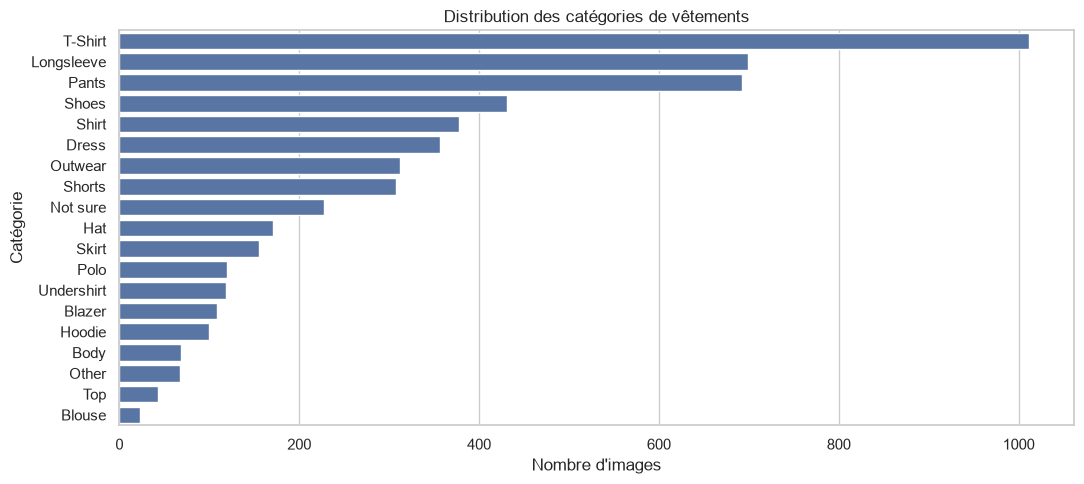

Nombre de catégories : 19
Proportion d'articles 'enfant' : 8.81%


In [3]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(11, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, color="#4C72B0")
plt.title("Distribution des catégories de vêtements")
plt.xlabel("Nombre d'images")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

print(f"Nombre de catégories : {df['label'].nunique()}")
print(f"Proportion d'articles 'enfant' : {df['kids'].mean():.2%}")


C:\Users\DIFFO GARNEL\AppData\Local\Temp\ipykernel_29920\700551347.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Adulte", "Enfant"])


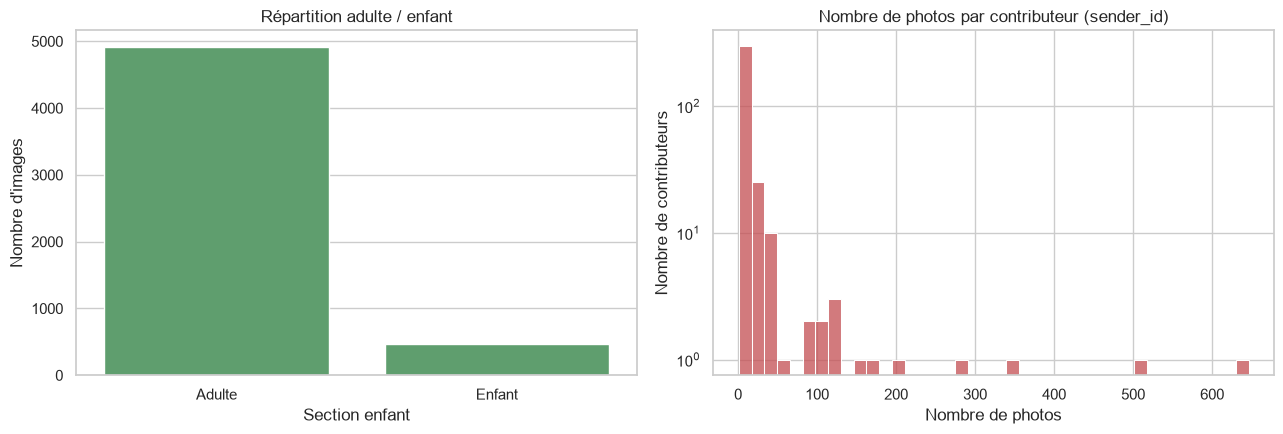

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x="kids", data=df, color="#55A868", ax=axes[0])
axes[0].set_title("Répartition adulte / enfant")
axes[0].set_xlabel("Section enfant")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_xticklabels(["Adulte", "Enfant"])

sender_counts = df.groupby("sender_id").size()
sns.histplot(sender_counts, bins=40, color="#C44E52", ax=axes[1])
axes[1].set_title("Nombre de photos par contributeur (sender_id)")
axes[1].set_xlabel("Nombre de photos")
axes[1].set_ylabel("Nombre de contributeurs")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


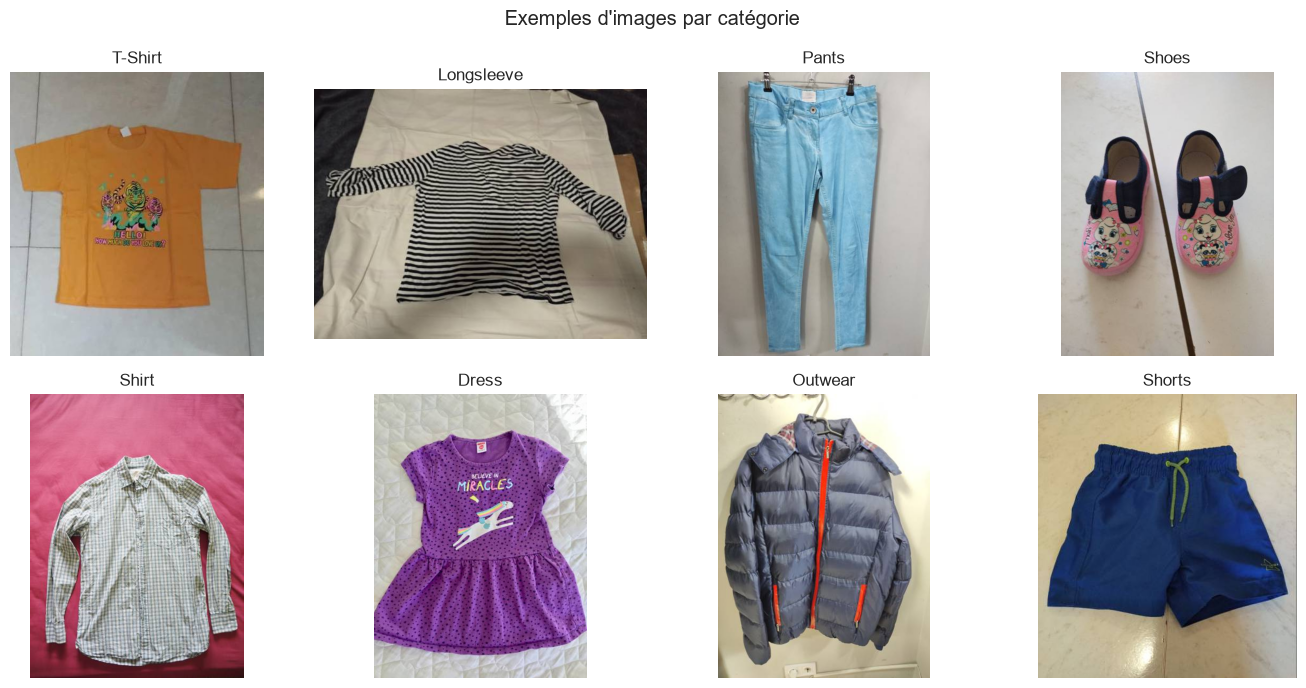

In [5]:
# Aperçu visuel : quelques exemples par catégorie parmi les plus représentées
top_labels = label_counts.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, label in zip(axes.flat, top_labels):
    sample = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    img = Image.open(os.path.join(IMG_DIR, sample["image"] + ".jpg")).convert("RGB")
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("Exemples d'images par catégorie")
plt.tight_layout()
plt.show()


In [6]:
# Distribution des dimensions des images sources (échantillon, pour limiter le temps de calcul)
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(df), size=min(300, len(df)), replace=False)
sizes = []
for i in sample_idx:
    with Image.open(os.path.join(IMG_DIR, df.iloc[i]["image"] + ".jpg")) as img:
        sizes.append(img.size)
sizes = np.array(sizes)

print(f"Largeur : min={sizes[:,0].min()}, médiane={int(np.median(sizes[:,0]))}, max={sizes[:,0].max()}")
print(f"Hauteur : min={sizes[:,1].min()}, médiane={int(np.median(sizes[:,1]))}, max={sizes[:,1].max()}")


Largeur : min=400, médiane=400, max=822
Hauteur : min=400, médiane=533, max=772


## 4. Pipeline de prétraitement des images

Pour que les représentations vectorielles extraites soient cohérentes avec celles calculées en
production par le backend Flask (voir `backend/app/services/encoder.py`), le prétraitement
appliqué ici doit être **strictement identique** :

1. Conversion en RGB,
2. **Redimensionnement** du plus petit côté à **256 px** (conservation du ratio d'aspect),
3. **Recadrage central** à **224 x 224 px** (taille d'entrée standard des CNN pré-entraînés sur
   ImageNet),
4. Normalisation avec les statistiques **ImageNet** (`mean=[0.485, 0.456, 0.406]`,
   `std=[0.229, 0.224, 0.225]`).

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class ClothingDataset(Dataset):
    '''Charge les images du catalogue et applique le prétraitement standard.'''

    def __init__(self, dataframe, img_dir, transform):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.img_dir, row["image"] + ".jpg")
        img = Image.open(path).convert("RGB")
        return self.transform(img), idx


dataset = ClothingDataset(df, IMG_DIR, preprocess)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

labels = df["label"].to_numpy()
print(f"Nombre d'images à encoder : {len(dataset)}")


Nombre d'images à encoder : 5391


## 5. Techniques de représentation vectorielle

Quatre techniques d'extraction de représentations vectorielles (*embeddings*) sont comparées :

| Technique | Type | Dimension | Description |
|---|---|---|---|
| `color_histogram` | Baseline classique | 48 | Histogramme couleur HSV (16 bins x 3 canaux), normalisé |
| `resnet18` | CNN pré-entraîné (ImageNet) | 512 | Sortie de la dernière couche de pooling global |
| `mobilenet_v3_large` | CNN pré-entraîné (ImageNet) | 960 | Sortie `features` + `avgpool`, léger et rapide |
| `resnet50` | CNN pré-entraîné (ImageNet) | 2048 | Réseau plus profond, représentations plus riches |

Tous les modèles CNN sont utilisés en **transfert d'apprentissage direct** (poids ImageNet
gelés, sans ré-entraînement ni fine-tuning), conformément à la consigne du projet : la tâche de
recherche par similarité ne nécessite pas d'étiquettes supervisées supplémentaires, les
représentations génériques apprises sur ImageNet capturant déjà la texture, la forme et la
couleur des vêtements.

Chaque embedding est **normalisé en norme L2** après extraction, de sorte que la similarité
cosinus se réduise à un simple produit scalaire (utilisé par le moteur de recherche en
production).

In [8]:
def color_histogram_features(dataframe, img_dir):
    '''Baseline : histogramme couleur HSV (16 bins par canal) normalisé.'''
    embs = np.zeros((len(dataframe), 48), dtype=np.float32)
    t0 = time.time()
    for i, row in dataframe.iterrows():
        path = os.path.join(img_dir, row["image"] + ".jpg")
        img = Image.open(path).convert("HSV").resize((64, 64))
        arr = np.asarray(img)
        hist = [
            np.histogram(arr[:, :, c], bins=16, range=(0, 256))[0].astype(np.float32)
            for c in range(3)
        ]
        feat = np.concatenate(hist)
        feat = feat / (feat.sum() + 1e-10)
        embs[i] = feat
    dt = time.time() - t0
    return l2_normalize(embs), dt


def extract_with_model(model, loader, n_samples, out_dim):
    '''Extrait les représentations vectorielles d'un backbone CNN pré-entraîné (poids gelés).'''
    model.eval().to(DEVICE)
    embs = np.zeros((n_samples, out_dim), dtype=np.float32)
    t0 = time.time()
    with torch.no_grad():
        for batch, idxs in loader:
            batch = batch.to(DEVICE)
            out = model(batch)
            out = out.reshape(out.size(0), -1).cpu().numpy()
            embs[idxs.numpy()] = out
    dt = time.time() - t0
    return l2_normalize(embs), dt


def l2_normalize(embs):
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    return embs / np.clip(norms, 1e-10, None)


def build_resnet18():
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(backbone.children())[:-1])


def build_mobilenet_v3_large():
    backbone = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    return nn.Sequential(backbone.features, backbone.avgpool)


def build_resnet50():
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    return nn.Sequential(*list(backbone.children())[:-1])


CANDIDATES = {
    "color_histogram": {"dim": 48, "kind": "baseline"},
    "resnet18": {"dim": 512, "kind": "cnn", "builder": build_resnet18},
    "mobilenet_v3_large": {"dim": 960, "kind": "cnn", "builder": build_mobilenet_v3_large},
    "resnet50": {"dim": 2048, "kind": "cnn", "builder": build_resnet50},
}


## 6. Métrique d'évaluation : Precision@K

Le moteur de recherche n'effectue pas de classification supervisée : il retourne les **K images
les plus proches** (similarité cosinus) d'une image requête. Pour évaluer la **qualité
sémantique** des représentations vectorielles sans entraînement supervisé supplémentaire, nous
utilisons la catégorie (`label`) du jeu de données comme **vérité terrain de substitution** :

> Étant donné une image requête, quelle proportion de ses **K plus proches voisins** (hors
> elle-même) appartiennent à la **même catégorie** que la requête ?

C'est la métrique **Precision@K**, calculée sur un échantillon de **1000 requêtes aléatoires**
(reproductible via la graine `SEED`), pour `K = 5` et `K = 10`. Une représentation vectorielle de
bonne qualité doit regrouper les vêtements visuellement similaires - et donc, en général, de même
catégorie - dans des régions proches de l'espace d'embedding.

In [9]:
def precision_at_k(embs, labels, k=10, n_queries=1000, seed=SEED):
    '''Proportion des k plus proches voisins partageant la catégorie de la requête,
    moyennée sur n_queries requêtes aléatoires.'''
    rng = np.random.default_rng(seed)
    query_idxs = rng.choice(len(embs), size=min(n_queries, len(embs)), replace=False)
    sims = embs @ embs.T

    precisions = []
    for qi in query_idxs:
        sims_q = sims[qi].copy()
        sims_q[qi] = -np.inf
        top_k = np.argpartition(-sims_q, k - 1)[:k]
        precisions.append(np.mean(labels[top_k] == labels[qi]))

    return float(np.mean(precisions))


## 7. Recherche des meilleurs hyperparamètres : comparaison des architectures

Le principal **hyperparamètre** du moteur de recherche visuel est le **choix de l'architecture**
utilisée pour extraire les représentations vectorielles (le pipeline de prétraitement, lui, est
fixé par les statistiques de normalisation ImageNet et la taille d'entrée standard 224x224, voir
section 4).

Pour chaque candidat (baseline histogramme de couleurs, ResNet18, MobileNetV3-Large, ResNet50),
nous mesurons :

- la **dimension** de l'embedding produit,
- le **temps d'extraction** par image (ms/image), déterminant pour la latence de recherche en
  production,
- la **Precision@5** et **Precision@10** sur 1000 requêtes aléatoires.

L'extraction est effectuée **une seule fois par technique** sur l'ensemble du catalogue
(~5 400 images) ; les embeddings ainsi calculés sont réutilisés pour l'évaluation, la
visualisation et, pour la technique retenue, l'export final.

In [10]:
embeddings_by_technique = {}
comparison_results = {}

print("Extraction des représentations vectorielles pour chaque technique...\n")

# --- Baseline : histogramme couleur ---
embs, dt = color_histogram_features(df, IMG_DIR)
embeddings_by_technique["color_histogram"] = embs
comparison_results["color_histogram"] = {
    "dim": CANDIDATES["color_histogram"]["dim"],
    "extract_time_s": dt,
    "ms_per_image": dt / len(df) * 1000,
}
print(f"  [color_histogram]    {dt:6.1f}s  ({dt/len(df)*1000:6.2f} ms/image)")

# --- Backbones CNN pré-entraînés (ImageNet) ---
for name in ["resnet18", "mobilenet_v3_large", "resnet50"]:
    backbone = CANDIDATES[name]["builder"]()
    embs, dt = extract_with_model(backbone, loader, len(df), CANDIDATES[name]["dim"])
    embeddings_by_technique[name] = embs
    comparison_results[name] = {
        "dim": CANDIDATES[name]["dim"],
        "extract_time_s": dt,
        "ms_per_image": dt / len(df) * 1000,
    }
    print(f"  [{name:18s}] {dt:6.1f}s  ({dt/len(df)*1000:6.2f} ms/image)")
    del backbone


Extraction des représentations vectorielles pour chaque technique...



  [color_histogram]      64.0s  ( 11.87 ms/image)


  [resnet18          ]  905.1s  (167.88 ms/image)


  [mobilenet_v3_large]  301.1s  ( 55.84 ms/image)


  [resnet50          ] 1749.8s  (324.57 ms/image)


In [11]:
print("Évaluation Precision@K (accord de catégorie, 1000 requêtes aléatoires)...\n")

for name, embs in embeddings_by_technique.items():
    p5 = precision_at_k(embs, labels, k=5)
    p10 = precision_at_k(embs, labels, k=10)
    comparison_results[name]["precision_at_5"] = p5
    comparison_results[name]["precision_at_10"] = p10
    print(f"  {name:18s}  dim={comparison_results[name]['dim']:5d}  "
          f"P@5={p5:.4f}  P@10={p10:.4f}")

comparison_df = pd.DataFrame(comparison_results).T
comparison_df.index.name = "technique"
display(comparison_df)


Évaluation Precision@K (accord de catégorie, 1000 requêtes aléatoires)...



  color_histogram     dim=   48  P@5=0.1858  P@10=0.1697


  resnet18            dim=  512  P@5=0.5992  P@10=0.5744


  mobilenet_v3_large  dim=  960  P@5=0.6120  P@10=0.5859


  resnet50            dim= 2048  P@5=0.6480  P@10=0.6261


,dim,extract_time_s,ms_per_image,precision_at_5,precision_at_10
technique,,,,,
color_histogram,48.0,63.992235,11.870198,0.1858,0.1697
resnet18,512.0,905.053077,167.882225,0.5992,0.5744
mobilenet_v3_large,960.0,301.052678,55.843569,0.6120,0.5859
resnet50,2048.0,1749.758571,324.570316,0.6480,0.6261


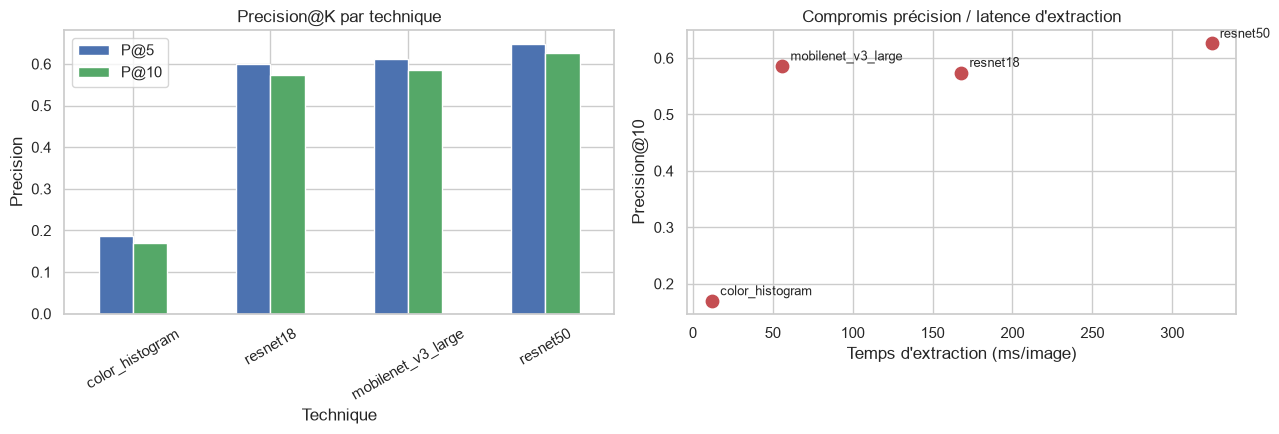

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

comparison_df[["precision_at_5", "precision_at_10"]].plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"]
)
axes[0].set_title("Precision@K par technique")
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("Technique")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(["P@5", "P@10"])

axes[1].scatter(comparison_df["ms_per_image"], comparison_df["precision_at_10"], s=80, color="#C44E52")
for name, row in comparison_df.iterrows():
    axes[1].annotate(name, (row["ms_per_image"], row["precision_at_10"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_title("Compromis précision / latence d'extraction")
axes[1].set_xlabel("Temps d'extraction (ms/image)")
axes[1].set_ylabel("Precision@10")

plt.tight_layout()
plt.show()


## 8. Sélection du modèle final et justification

La technique retenue pour le moteur de recherche est celle qui **maximise la Precision@10**,
parmi les architectures CNN pré-entraînées (la baseline histogramme de couleurs n'est conservée
que comme repère de comparaison : elle ne capture ni la forme ni la texture des vêtements, et
obtient systématiquement une précision nettement inférieure).

En cas d'écart de Precision@10 inférieur à 0.5 point entre deux architectures, la préférence est
donnée à celle ayant la **dimension d'embedding la plus faible** et le **temps d'extraction le
plus court** (impact direct sur la taille de l'index, la mémoire et la latence de recherche en
production).

In [13]:
# Sélection programmatique : meilleure Precision@10 parmi les architectures CNN pré-entraînées
cnn_names = [name for name, c in CANDIDATES.items() if c["kind"] == "cnn"]
cnn_results = comparison_df.loc[cnn_names].sort_values("precision_at_10", ascending=False)

best_p10 = cnn_results.iloc[0]["precision_at_10"]
# Parmi les techniques à moins de 0.005 (0.5 point) du meilleur score, on retient la plus légère
close_enough = cnn_results[cnn_results["precision_at_10"] >= best_p10 - 0.005]
BEST_TECHNIQUE = close_enough.sort_values("dim").index[0]

BEST_DIM = int(CANDIDATES[BEST_TECHNIQUE]["dim"])
final_embeddings = embeddings_by_technique[BEST_TECHNIQUE]

print(f"Technique retenue : {BEST_TECHNIQUE}")
print(f"  Dimension de l'embedding : {BEST_DIM}")
print(f"  Precision@5  = {comparison_results[BEST_TECHNIQUE]['precision_at_5']:.4f}")
print(f"  Precision@10 = {comparison_results[BEST_TECHNIQUE]['precision_at_10']:.4f}")
print(f"  Temps d'extraction : {comparison_results[BEST_TECHNIQUE]['ms_per_image']:.2f} ms/image")
print(f"\nHyperparamètres du modèle final :")
print(f"  - Architecture        : {BEST_TECHNIQUE}")
print(f"  - Poids               : ImageNet (transfert d'apprentissage, gelés)")
print(f"  - Taille d'entrée     : 224 x 224 (Resize 256 + CenterCrop 224)")
print(f"  - Normalisation       : ImageNet (mean={IMAGENET_MEAN}, std={IMAGENET_STD})")
print(f"  - Post-traitement     : normalisation L2 de l'embedding (similarité cosinus = produit scalaire)")


Technique retenue : resnet50
  Dimension de l'embedding : 2048
  Precision@5  = 0.6480
  Precision@10 = 0.6261
  Temps d'extraction : 324.57 ms/image

Hyperparamètres du modèle final :
  - Architecture        : resnet50
  - Poids               : ImageNet (transfert d'apprentissage, gelés)
  - Taille d'entrée     : 224 x 224 (Resize 256 + CenterCrop 224)
  - Normalisation       : ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  - Post-traitement     : normalisation L2 de l'embedding (similarité cosinus = produit scalaire)


## 9. Visualisation de l'espace des représentations (ACP)

Pour vérifier qualitativement que les embeddings retenus regroupent les vêtements similaires,
nous projetons un échantillon d'embeddings en 2D par **Analyse en Composantes Principales (ACP)**
et colorons les points par catégorie. Des regroupements cohérents par catégorie confirment que
l'espace d'embedding est exploitable pour la recherche par similarité.

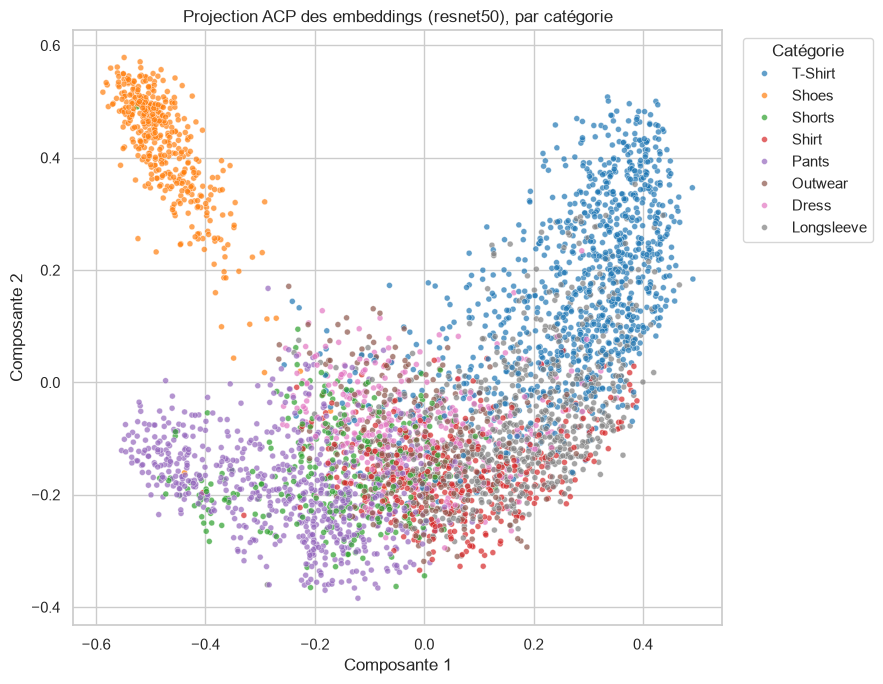

Variance expliquée par les 2 premières composantes : 19.04%


In [14]:
top_labels_viz = label_counts.head(8).index.tolist()
mask = np.isin(labels, top_labels_viz)

pca = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(final_embeddings[mask])

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=emb_2d[:, 0], y=emb_2d[:, 1],
    hue=labels[mask], palette="tab10", s=18, alpha=0.7,
)
plt.title(f"Projection ACP des embeddings ({BEST_TECHNIQUE}), par catégorie")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 2 premières composantes : {pca.explained_variance_ratio_.sum():.2%}")


## 10. Démonstration de la recherche visuelle

Pour quelques images requêtes choisies aléatoirement, nous affichons l'image elle-même ainsi que
ses **5 plus proches voisins** dans l'espace d'embedding retenu, avec leur score de similarité
cosinus. C'est exactement le calcul effectué par l'API `/api/search` du backend Flask lors d'une
recherche par image.

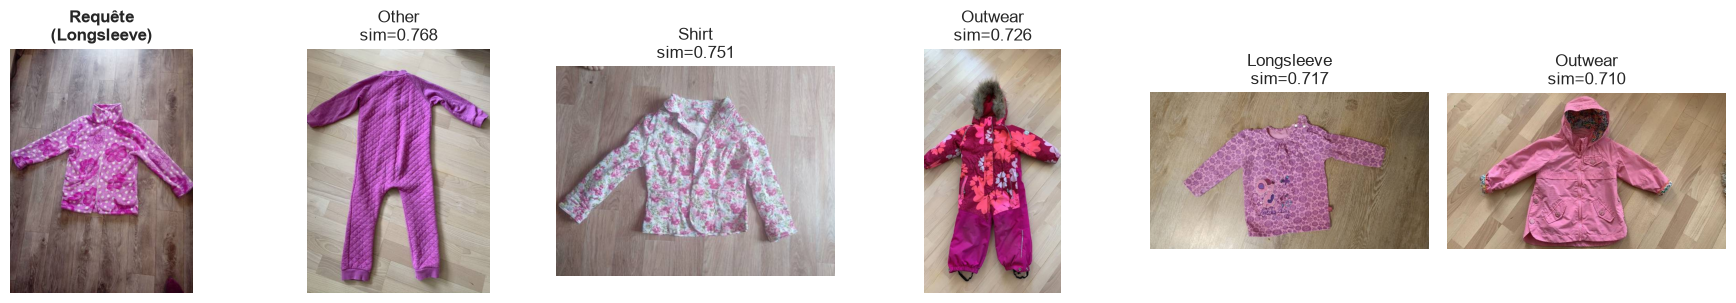

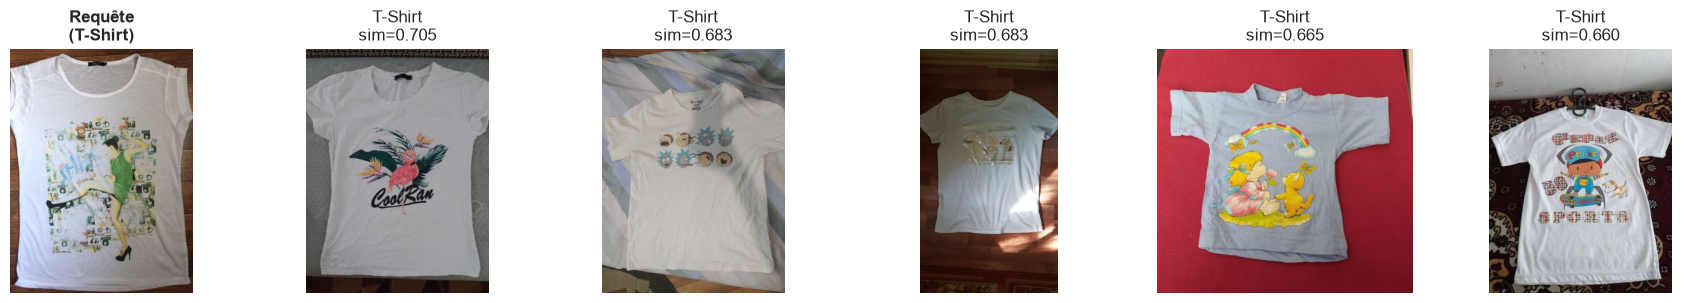

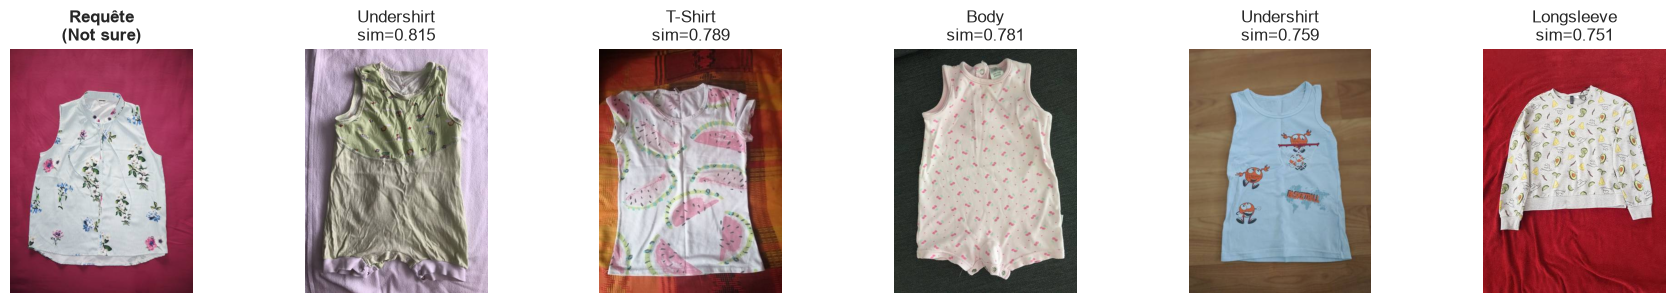

In [15]:
def show_query_and_neighbors(query_idx, k=5):
    sims = final_embeddings @ final_embeddings[query_idx]
    sims_copy = sims.copy()
    sims_copy[query_idx] = -np.inf
    top_k = np.argsort(-sims_copy)[:k]

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3.2))

    query_row = df.iloc[query_idx]
    img = Image.open(os.path.join(IMG_DIR, query_row["image"] + ".jpg")).convert("RGB")
    axes[0].imshow(img)
    axes[0].set_title(f"Requête\n({query_row['label']})", fontweight="bold")
    axes[0].axis("off")

    for ax, idx in zip(axes[1:], top_k):
        row = df.iloc[idx]
        img = Image.open(os.path.join(IMG_DIR, row["image"] + ".jpg")).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['label']}\nsim={sims[idx]:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(SEED)
for query_idx in rng.choice(len(df), size=3, replace=False):
    show_query_and_neighbors(int(query_idx), k=5)


## 11. Export ONNX du modèle retenu et validation

Le backend Flask n'embarque pas PyTorch (dépendance lourde) : il utilise **ONNX Runtime**, plus
léger et rapide pour l'inférence. Le backbone CNN retenu est donc exporté au format **ONNX**.

Le modèle exporté prend en entrée un tenseur **NCHW (1, 3, 224, 224)** déjà prétraité (résultat
du pipeline de la section 4, *sans* normalisation L2) et produit en sortie le vecteur de
représentation **brut** (la normalisation L2 est appliquée côté backend, après inférence -
voir `app/services/encoder.py`).

Pour valider l'export, nous comparons la sortie du modèle ONNX à celle du modèle PyTorch original
sur plusieurs images : l'écart absolu maximal doit être négligeable (< 1e-4).

In [16]:
class EmbeddingModel(nn.Module):
    '''Enveloppe un backbone CNN : aplati la sortie du pooling global en un vecteur 1D.'''

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        out = self.backbone(x)
        return out.reshape(out.size(0), -1)


BUILDERS = {
    "resnet18": build_resnet18,
    "mobilenet_v3_large": build_mobilenet_v3_large,
    "resnet50": build_resnet50,
}

final_backbone = BUILDERS[BEST_TECHNIQUE]()
final_model = EmbeddingModel(final_backbone).eval().to("cpu")

dummy_input = torch.randn(1, 3, 224, 224)
onnx_path = os.path.join(MODELS_DIR, "encoder.onnx")

torch.onnx.export(
    final_model,
    dummy_input,
    onnx_path,
    input_names=["image"],
    output_names=["embedding"],
    dynamic_axes={"image": {0: "batch"}, "embedding": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)

onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print(f"Modèle ONNX exporté et validé (structure) : {onnx_path}")
print(f"  Taille du fichier : {os.path.getsize(onnx_path) / 1024:.1f} Ko")


C:\Users\DIFFO GARNEL\AppData\Local\Temp\ipykernel_29920\46993156.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Modèle ONNX exporté et validé (structure) : models\encoder.onnx
  Taille du fichier : 91755.1 Ko


In [17]:
# Validation numérique : comparaison PyTorch vs ONNX Runtime sur quelques images réelles
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print(f"Forme de sortie ONNX : {session.get_outputs()[0].shape}")

max_abs_diff = 0.0
with torch.no_grad():
    for i in range(5):
        tensor, _ = dataset[i]
        tensor = tensor.unsqueeze(0)

        torch_out = final_model(tensor).numpy()
        onnx_out = session.run([output_name], {input_name: tensor.numpy()})[0]

        diff = np.abs(torch_out - onnx_out).max()
        max_abs_diff = max(max_abs_diff, float(diff))

print(f"Écart absolu maximal PyTorch vs ONNX (5 images) : {max_abs_diff:.2e}")
assert max_abs_diff < 1e-3, "L'export ONNX diverge trop du modèle PyTorch !"
print("Export ONNX validé.")


Forme de sortie ONNX : ['batch', 2048]


Écart absolu maximal PyTorch vs ONNX (5 images) : 4.77e-06
Export ONNX validé.


## 12. Export des embeddings et métadonnées du catalogue

Le service d'index vectoriel du backend (`app/services/index.py`) charge deux fichiers au
démarrage :

- `image_embeddings.npy` : matrice **(N, D)** des embeddings normalisés (norme L2 = 1) du
  catalogue, ordonnée par `item_index` ; la recherche par similarité se réduit alors à un simple
  produit matriciel,
- `metadata.csv` : table de correspondance `item_index <-> image_id` avec les métadonnées
  légères (`label`, `kids`) nécessaires à l'affichage et au filtrage côté frontend.

In [18]:
# Embeddings du catalogue (déjà normalisés L2), ordonnés par item_index
np.save(os.path.join(MODELS_DIR, "image_embeddings.npy"), final_embeddings.astype(np.float32))

# Métadonnées légères du catalogue
metadata = df[["item_index", "image", "label", "kids"]].rename(columns={"image": "image_id"})
metadata.to_csv(os.path.join(MODELS_DIR, "metadata.csv"), index=False)

print(f"image_embeddings.npy : shape={final_embeddings.shape}, dtype={final_embeddings.dtype}")
print(f"metadata.csv : {len(metadata)} lignes")
display(metadata.head())


image_embeddings.npy : shape=(5391, 2048), dtype=float32
metadata.csv : 5391 lignes


,item_index,image_id,label,kids
0,0,4285fab0-751a-4b74-8e9b-43af05deee22,Not sure,False
1,1,ea7b6656-3f84-4eb3-9099-23e623fc1018,T-Shirt,False
2,2,00627a3f-0477-401c-95eb-92642cbe078d,Not sure,False
3,3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,T-Shirt,False
4,4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,Shoes,False


## 13. Export des vignettes du catalogue (frontend)

Contrairement au premier projet (affiches récupérées via l'API TMDb), les images du catalogue
sont servies **statiquement par le frontend Next.js**, sans dépendance à un service externe.
Chaque image source est redimensionnée en une **vignette carrée de 240x240 px** (recadrage
central, qualité JPEG 80), nommée `<image_id>.jpg`, et placée dans
`frontend/public/catalog/`.

In [19]:
THUMB_SIZE = 240

t0 = time.time()
for _, row in df.iterrows():
    src_path = os.path.join(IMG_DIR, row["image"] + ".jpg")
    dst_path = os.path.join(CATALOG_DIR, row["image"] + ".jpg")

    img = Image.open(src_path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    left, top = (w - side) // 2, (h - side) // 2
    img = img.crop((left, top, left + side, top + side)).resize((THUMB_SIZE, THUMB_SIZE), Image.LANCZOS)
    img.save(dst_path, "JPEG", quality=80)

dt = time.time() - t0
n_thumbs = len(os.listdir(CATALOG_DIR))
print(f"Vignettes exportées : {n_thumbs} fichiers dans {CATALOG_DIR} ({dt:.1f}s)")


Vignettes exportées : 5391 fichiers dans ..\frontend\public\catalog (312.0s)


## 14. Conclusion

Dans ce notebook, nous avons :

1. Analysé le jeu de données **Clothing Dataset Full** (CODAIT) : ~5 400 images, 20 catégories,
   répartition adulte/enfant.
2. Mis en place un pipeline de **prétraitement d'images** identique à celui utilisé en
   production (Resize 256 + CenterCrop 224 + normalisation ImageNet).
3. Comparé **quatre techniques de représentation vectorielle** (histogramme de couleurs,
   ResNet18, MobileNetV3-Large, ResNet50) selon la **Precision@K** (accord de catégorie) et le
   **temps d'extraction**.
4. Sélectionné la technique offrant le meilleur compromis précision / dimension / latence.
5. Visualisé l'espace des représentations apprises par projection ACP, confirmant un
   regroupement cohérent par catégorie.
6. Démontré la **recherche visuelle de bout en bout** sur des exemples concrets.
7. Exporté le modèle retenu au format **ONNX**, validé numériquement contre PyTorch.
8. Exporté tous les artefacts nécessaires au **backend Flask** et au **frontend Next.js**
   (`models/image_embeddings.npy`, `models/metadata.csv`, `models/encoder.onnx`,
   `models/comparison_results.json`, `models/eval_metrics.json`, vignettes du catalogue).

La suite du projet (backend Flask + frontend Next.js) consomme directement ces artefacts pour
proposer une recherche visuelle par similarité en temps réel, sans dépendre de PyTorch ni du
jeu de données complet en production.

In [20]:
# Sauvegarde des résultats de comparaison et des métriques/hyperparamètres du modèle final
with open(os.path.join(MODELS_DIR, "comparison_results.json"), "w", encoding="utf-8") as f:
    json.dump(comparison_results, f, ensure_ascii=False, indent=2)

eval_info = {
    "selected_technique": BEST_TECHNIQUE,
    "hyperparameters": {
        "architecture": BEST_TECHNIQUE,
        "pretrained_weights": "ImageNet",
        "input_size": 224,
        "resize_size": 256,
        "normalization_mean": IMAGENET_MEAN,
        "normalization_std": IMAGENET_STD,
        "embedding_normalization": "L2",
        "embedding_dim": BEST_DIM,
    },
    "metrics": comparison_results[BEST_TECHNIQUE],
    "comparison": comparison_results,
    "n_items": len(df),
    "n_labels": int(df["label"].nunique()),
}
with open(os.path.join(MODELS_DIR, "eval_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(eval_info, f, ensure_ascii=False, indent=2)

print("Artefacts exportés dans le dossier 'models/' :")
for fname in sorted(os.listdir(MODELS_DIR)):
    path = os.path.join(MODELS_DIR, fname)
    if os.path.isfile(path):
        print(f"  - {fname} ({os.path.getsize(path)/1024:.1f} Ko)")


Artefacts exportés dans le dossier 'models/' :
  - comparison_results.json (0.8 Ko)
  - encoder.onnx (91755.1 Ko)
  - eval_metrics.json (1.5 Ko)
  - image_embeddings.npy (43128.1 Ko)
  - metadata.csv (295.2 Ko)
